In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

tf.random.set_seed(42)
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q datasets

from datasets import load_dataset
from PIL import Image
import shutil

N_TRAIN_PER_CLASS = 1500
N_VAL_PER_CLASS = 300

print("Downloading microsoft/cats_vs_dogs from Hugging Face (this may take a few minutes)...")
hf_ds = load_dataset("microsoft/cats_vs_dogs", split="train")
print(f"Total images available: {len(hf_ds)}")
print(hf_ds.features)   # label 0 = cat, 1 = dog

README.md:   0%|          | 0.00/8.16k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  330MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  391MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

Total images available: 23410
{'image': Image(mode=None, decode=True), 'labels': ClassLabel(names=['cat', 'dog'])}


In [ ]:
base_dir = "/content/cats_and_dogs_filtered"
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")
for split_dir in (train_dir, val_dir):
    for cls in ("cats", "dogs"):
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

LABEL_TO_DIR = {0: "cats", 1: "dogs"}
counts = {0: 0, 1: 0}
needed_train = N_TRAIN_PER_CLASS
needed_val = N_VAL_PER_CLASS
saved = {("train", 0): 0, ("train", 1): 0, ("val", 0): 0, ("val", 1): 0}

for example in hf_ds:
    label = example["labels"] if "labels" in example else example["label"]
    if label not in (0, 1):
        continue
    if saved[("train", label)] < needed_train:
        split, idx = "train", saved[("train", label)]
        out_dir = train_dir
    elif saved[("val", label)] < needed_val:
        split, idx = "val", saved[("val", label)]
        out_dir = val_dir
    else:
        continue

    img = example["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    img.save(os.path.join(out_dir, LABEL_TO_DIR[label], f"{label}_{idx}.jpg"))
    saved[(split, label)] += 1

    if all(v >= needed_train for k, v in saved.items() if k[0] == "train") and \
       all(v >= needed_val for k, v in saved.items() if k[0] == "val"):
        break

print("Train cats:", len(os.listdir(os.path.join(train_dir, "cats"))))
print("Train dogs:", len(os.listdir(os.path.join(train_dir, "dogs"))))
print("Val cats:", len(os.listdir(os.path.join(val_dir, "cats"))))
print("Val dogs:", len(os.listdir(os.path.join(val_dir, "dogs"))))

Train cats: 1500
Train dogs: 1500
Val cats: 300
Val dogs: 300


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42,
)
val_ds = keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42,
)

class_names = train_ds.class_names
print("Classes:", class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

normalization = layers.Rescaling(1.0 / 255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (data_augmentation(normalization(x), training=True), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(AUTOTUNE)

Found 3000 files belonging to 2 classes.
Found 600 files belonging to 2 classes.
Classes: ['cats', 'dogs']


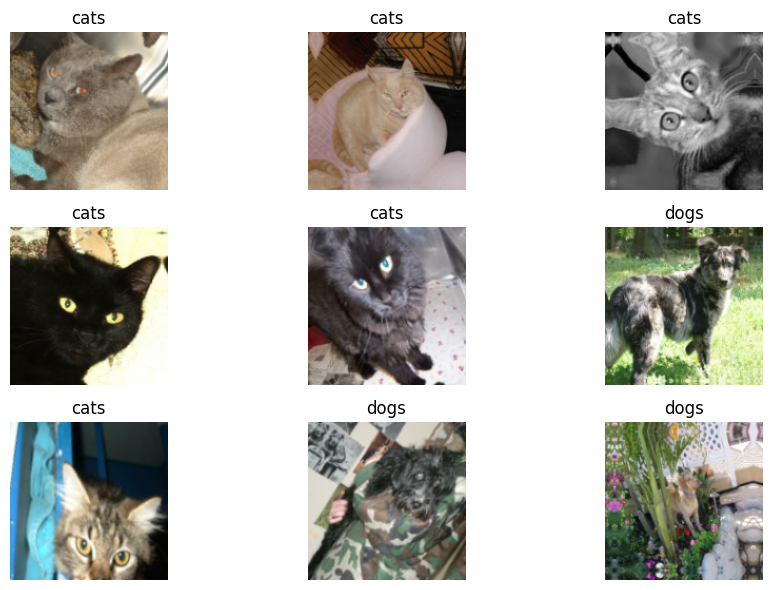

In [ ]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),   # binary classification: cat (0) vs dog (1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,896,961 (11.05 MB)

 Trainable params: 2,896,257 (11.05 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
EPOCHS = 20

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 271ms/step - accuracy: 0.5963 - loss: 0.9807 - val_accuracy: 0.5000 - val_loss: 0.7764
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.6470 - loss: 0.6906 - val_accuracy: 0.5000 - val_loss: 1.1110
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.6867 - loss: 0.6200 - val_accuracy: 0.5733 - val_loss: 1.0284
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.6963 - loss: 0.5848 - val_accuracy: 0.6733 - val_loss: 0.7735
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.7000 - loss: 0.5780 - val_accuracy: 0.6833 - val_loss: 0.6020
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.7177 - loss: 0.5583 - val_accuracy: 0.7150 - val_loss: 0.5725
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.7293 - loss: 0.5424 - val_accuracy: 0.7350 - val_loss: 0.5424
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step - accuracy: 0.7307 - loss: 0.5274 - val_accu

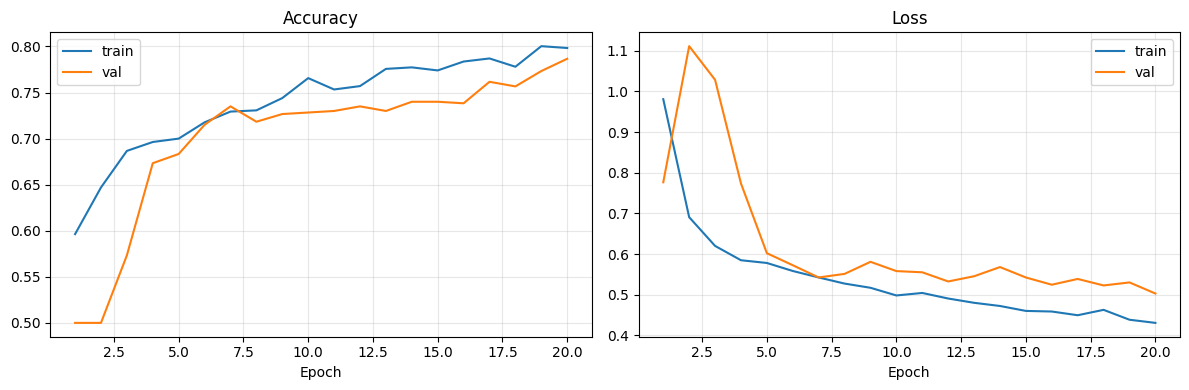

Best val_accuracy: 0.7867


In [ ]:
h = history.history
epochs_range = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, h["accuracy"], label="train")
axes[0].plot(epochs_range, h["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, h["loss"], label="train")
axes[1].plot(epochs_range, h["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("catsdogs_training_curves.png", dpi=150)
plt.show()

print(f"Best val_accuracy: {max(h['val_accuracy']):.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten().tolist())
    y_pred.extend((preds.flatten() > 0.5).astype(int).tolist())

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows=true, cols=pred, order=[cat, dog]):")
print(cm)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

Confusion matrix (rows=true, cols=pred, order=[cat, dog]):
[[242  58]
 [ 70 230]]

              precision    recall  f1-score   support

        cats       0.78      0.81      0.79       300
        dogs       0.80      0.77      0.78       300

    accuracy                           0.79       600
   macro avg       0.79      0.79      0.79       600
weighted avg       0.79      0.79      0.79       600



In [ ]:
 model.save("cats_dogs_model.keras")
print("Saved model to cats_dogs_model.keras")


from google.colab import files
files.download("cats_dogs_model.keras")

Saved model to cats_dogs_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving ff.jpg to ff.jpg


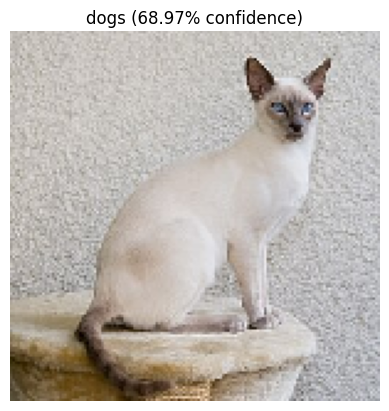

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()   # pick an image file from your computer

for fname in uploaded.keys():
    img = load_img(fname, target_size=IMG_SIZE)
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    pred = model.predict(arr, verbose=0)[0][0]
    label = class_names[1] if pred > 0.5 else class_names[0]
    confidence = pred if pred > 0.5 else 1 - pred
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label} ({confidence:.2%} confidence)")
    plt.show()

In [ ]:
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")


import numpy as np
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0).flatten()
    for i in range(10):
        true_label = class_names[int(labels[i].numpy()[0])]
        pred_label = class_names[1] if preds[i] > 0.5 else class_names[0]
        print(f"true={true_label:5s}  pred={pred_label:5s}  score={preds[i]:.3f}")

Best val_accuracy: 0.7867
Best val_loss: 0.5029
true=dogs   pred=dogs   score=0.992
true=dogs   pred=dogs   score=0.844
true=cats   pred=cats   score=0.045
true=dogs   pred=dogs   score=0.868
true=dogs   pred=dogs   score=0.991
true=dogs   pred=cats   score=0.370
true=dogs   pred=dogs   score=0.943
true=dogs   pred=dogs   score=0.722
true=cats   pred=cats   score=0.103
true=cats   pred=cats   score=0.010
